In [130]:
import sinter
import stim
from typing import List
from mwpf import SinterMWPFDecoder
import matplotlib.pyplot as plt
import os

In [131]:
# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
noise = [
    0.001,
    0.004,
    0.005,
    0.006,
    0.0065,
    0.007,
    0.0075,
    0.008,
    0.009,
    0.01,
    0.011,
    0.012,
]
code_distance = [3, 5, 7, 9]
MAX_SHOTS = 1_000_000
MAX_ERRORS = 5_000
task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 3,
            distance=d,
            after_clifford_depolarization=p,
            after_reset_flip_probability=p,
            before_measure_flip_probability=p,
            before_round_data_depolarization=p,
        ),
        json_metadata={
            "d": d,
            "p": p,
            "circuit": "rotated_memory_x",
            "r": d * 3,
            "decoder": "pymatching",
        },
    )
    for p in noise
    for d in code_distance
]

tasks = [sinter.Task(**task) for task in task_configs]

pymatching_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count() - 2,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=MAX_SHOTS,
    max_errors=MAX_ERRORS,
    print_progress=True,
    save_resume_filepath="../datasets/rotated_memory_x_pymatching/2025_11_13_pthresh.csv",
    count_observable_error_combos=True,
    count_detection_events=True,
)

Starting 14 workers...


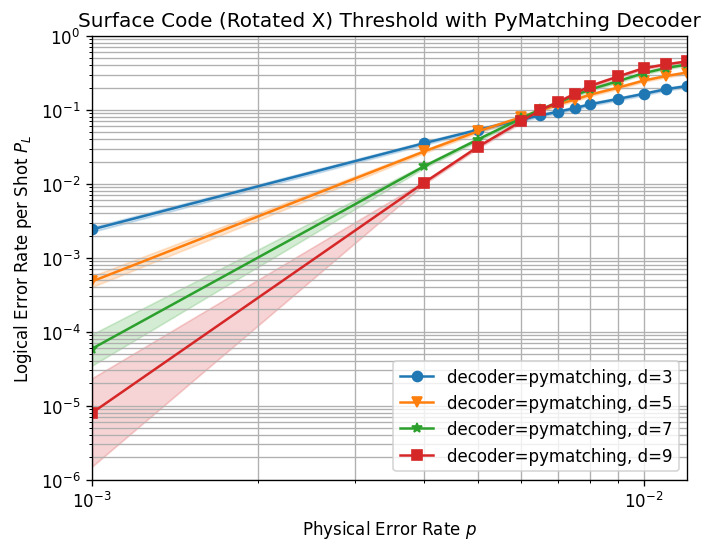

In [132]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
)
ax.loglog()
ax.set_ylim(1e-6, 1e0)
ax.set_xlim(1e-3, 1.2e-2)
ax.set_title("Surface Code (Rotated X) Threshold with PyMatching Decoder")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

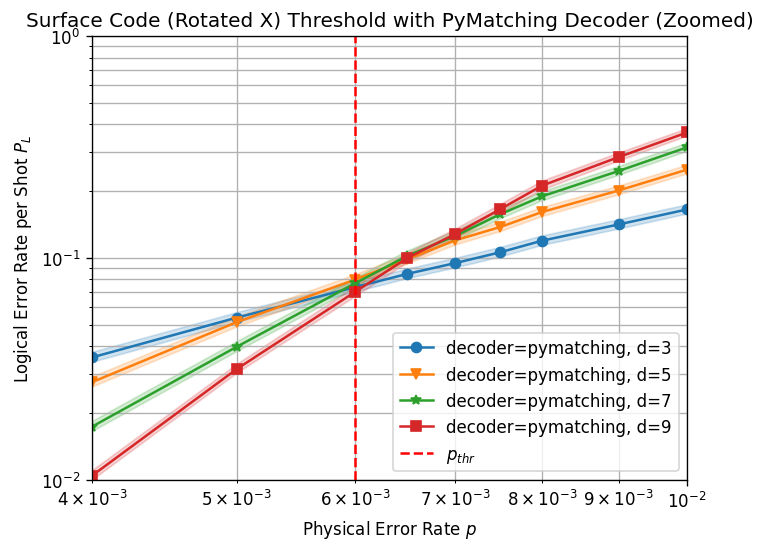

In [133]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
)
ax.loglog()
ax.set_ylim(1e-2, 1e0)
ax.set_xlim(4e-3, 1e-2)
ax.set_title("Surface Code (Rotated X) Threshold with PyMatching Decoder (Zoomed)")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")

# Plot a vertical line at pthresh
plt.axvline(x=6e-3, color="r", linestyle="--", label="$p_{thr}$")

ax.legend()
fig.set_dpi(120)

In [ ]:
# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
noise = [
    0.001,
    0.004,
    0.005,
    0.006,
    0.0065,
    0.007,
    0.0075,
    0.008,
    0.009,
    0.01,
    0.011,
    0.012,
]
code_distance = [3, 5, 7, 9]
MAX_SHOTS = 50_000
MAX_ERRORS = 1_000
task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 3,
            distance=d,
            after_clifford_depolarization=p,
            after_reset_flip_probability=p,
            before_measure_flip_probability=p,
            before_round_data_depolarization=p,
        ),
        json_metadata={
            "d": d,
            "p": p,
            "label": "rotated_memory_x",
            "r": d * 3,
            "decoder": "mwpf",
        },
    )
    for p in noise
    for d in code_distance
]

tasks = [sinter.Task(**task) for task in task_configs]

mwpf_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count() - 2,
    tasks=tasks,
    decoders=["mwpf"],
    custom_decoders={
        "mwpf": SinterMWPFDecoder(
            decoder_type="SolverSerialUnionFind",
            timeout=3,
            cluster_node_limit=50,
            with_progress=True,
            # benchmark_suite_filename="../datasets/rotated_memory_x_mwpf/benchmark.csv",
            # trace_filename="../datasets/rotated_memory_x_mwpf_SolverSerialJointSingleHair/v1/trace.csv",
        )
    },
    max_shots=MAX_SHOTS,
    max_errors=MAX_ERRORS,
    print_progress=True,
    count_observable_error_combos=True,
    count_detection_events=True,
    save_resume_filepath="../datasets/rotated_memory_x_mwpf_SolverSerialUnionFind/2025_11_13_pthresh.csv",
)

Starting 14 workers...
48 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                        
        1    mwpf   ?      50000        1000 d=3,p=0.001,label=rotated_memory_x,r=9,decoder=mwpf  
        1    mwpf   ?      50000        1000 d=5,p=0.001,label=rotated_memory_x,r=15,decoder=mwpf 
        1    mwpf   ?      50000        1000 d=7,p=0.001,label=rotated_memory_x,r=21,decoder=mwpf 
        1    mwpf   ?      50000        1000 d=9,p=0.001,label=rotated_memory_x,r=27,decoder=mwpf 
        1    mwpf   ?      50000        1000 d=3,p=0.004,label=rotated_memory_x,r=9,decoder=mwpf  
        1    mwpf   ?      50000        1000 d=5,p=0.004,label=rotated_memory_x,r=15,decoder=mwpf 
        1    mwpf   ?      50000        1000 d=7,p=0.004,label=rotated_memory_x,r=21,decoder=mwpf 
        1    mwpf   ?      50000        1000 d=9,p=0.004,label=rotated_memory_x,r=27,decoder=mwpf 
        1    mwpf   ?      50000        1000 d=3,p=0.005,label=rotated_

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=mwpf_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax.set_ylim(1e-6, 1e0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title(
    "Surface Code Error Rates Per Shot (MPWF Baseline, Init |+>, Measure X Basis)"
)
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=mwpf_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
    failure_units_per_shot_func=lambda stat: stat.json_metadata["r"],
)
ax.set_ylim(1e-6, 1e0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title(
    "Surface Code Error Rates Per Round (MPWF Builtin, Init |+>, Measure X Basis)"
)
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [ ]:
import itertools
from uuid import uuid4


from dataclasses import replace
import mwpf.ref_circuit

# TODO - if we use individual errors e.g. X_ERROR Y_ERROR Z_ERROR instead of randomized DEPOLARIZE1/2 noise
CONVERT_TO_ERASURE_NOISE = ("DEPOLARIZE1", "DEPOLARIZE2")
noise = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]
code_distance = [3, 5, 7, 9]
MAX_SHOTS = 50000
MAX_ERRORS = 5000


def erasure_conversion(
    task_config: dict, conversion_factor: int = 1, add_detectors: bool = True
) -> dict:
    """Converts random pauli noise instructions (e.g. DEPOLARIZE1, DEPOLARIZE2) to HERALDED_ERASE instructions

    See notes in https://github.com/yuewuo/mwpf/blob/main/src/python/mwpf/ref_circuit.py
    for explanation of why reference circuits are needed to keep track of measurement indices w/ heralded errors
    """
    circuit = task_config["circuit"]
    json_metadata = task_config["json_metadata"]
    ref_circuit = mwpf.ref_circuit.RefCircuit.of(circuit)

    instructions: list[mwpf.ref_circuit.RefInstruction] = []
    for instruction in ref_circuit:
        if instruction.name in CONVERT_TO_ERASURE_NOISE:
            p = instruction.gate_args[0]
            instructions.append(replace(instruction, gate_args=[p * conversion_factor]))
            new_instruction = mwpf.ref_circuit.RefInstruction.new_heralded_erase(
                instruction.targets, min(1, 4 / 3 * p * conversion_factor)
            )
            instructions.append(new_instruction)
            if add_detectors is True:
                for rec in new_instruction.recs:
                    instructions.append(
                        mwpf.ref_circuit.RefInstruction.new_detector((rec,))
                    )
        else:
            instructions.append(instruction)
    converted_metadata = json_metadata.copy()
    converted_metadata["p_erase"] = converted_metadata["p"]
    converted_metadata["p"] = 0
    run_id = converted_metadata["run_id"]

    converted_circuit = mwpf.ref_circuit.RefCircuit.of(instructions).circuit()
    new_task_config = dict(
        circuit=converted_circuit,
        json_metadata=converted_metadata,
        decoder=f"mwpf__{run_id}",
    )
    return new_task_config


# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={
            "d": d,
            "p": p,
            "label": "rotated_memory_x",
            "run_id": str(uuid4()),
            "r": d * 3,
            "decoder": "mwpf_erasure",
        },
    )
    for d in code_distance
    for p in noise
]

converted_erasure_task_configs = list(map(erasure_conversion, task_configs))
tasks = [sinter.Task(**task) for task in converted_erasure_task_configs]


def build_custom_decoders(task_configs):
    return {
        f"mwpf__{task_config['json_metadata']['run_id']}": SinterMWPFDecoder(
            decoder_type="SolverSerialJointSingleHair",
            cluster_node_limit=50,
            with_progress=True,
            timeout=10,
        ).with_circuit(task_config["circuit"])
        for task_config in task_configs
    }


erasure_collected_stats = sinter.collect(
    num_workers=os.cpu_count() - 2,
    tasks=tasks,
    custom_decoders=build_custom_decoders(converted_erasure_task_configs),
    count_observable_error_combos=True,
    count_detection_events=True,
    print_progress=True,
    max_shots=MAX_SHOTS,
    max_errors=MAX_ERRORS,
    save_resume_filepath="../datasets/rotated_memory_x_mwpf_SolverSerialJointSingleHair_erasure/v1/shots.csv",
)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_collected_stats,
    x_func=lambda stats: stats.json_metadata["p_erase"],
    group_func=lambda stats: stats.json_metadata["d"],
    line_fits=("linear", "linear"),
)
ax.set_ylim(1e-7, 1e-0)
ax.set_xlim(1e-2, 3e-1)
ax.loglog()
ax.set_title(
    "Surface Code Error Rates Per Shot w/ Erasure (MPWF Hypergraph, Init |+>, Measure X Basis)"
)
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_collected_stats,
    x_func=lambda stats: stats.json_metadata["p_erase"],
    group_func=lambda stats: stats.json_metadata["d"],
    failure_units_per_shot_func=lambda stat: stat.json_metadata["r"],
    line_fits=("linear", "linear"),
)
# ax.set_ylim(1e-1, 1e-0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title(
    "Surface Code Discard Rate Per Round w/ Erasure (MPWF Hypergraph, Init |+>, Measure X Basis)"
)
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Discard Rate per Round")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [ ]:
for s in pymatching_stats:
    if s.json_metadata.get("decoder") is None:
        s.json_metadata["decoder"] = "pymatching"
for s in mwpf_stats:
    if s.json_metadata.get("decoder") is None:
        s.json_metadata["decoder"] = "mwpf"
for s in erasure_collected_stats:
    if s.json_metadata.get("decoder") is None:
        s.json_metadata["decoder"] = "mwpf_erasure"

In [ ]:
fig, ax = plt.subplots(1, 1)
import numpy as np

plt.rcParams["image.cmap"] = "tab20c"

# def custom_plot_markers(group_key):
#     if 'pymatching' in group_key:
#         color = "red"
#     elif 'erasure' in group_key:

#     return {
#         'color': (
#             'red' if 'pymatching' in group_key
#             'blue'
#             else 'blue'
#         )
#     }
sinter.plot_error_rate(
    ax=ax,
    stats=mwpf_stats + pymatching_stats + erasure_collected_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
    failure_units_per_shot_func=lambda stat: stat.json_metadata["r"],
    # plot_args_func=lambda idx, group_key, stats: custom_plot_markers(group_key))
)
ax.set_ylim(1e-6, 1e0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title(
    "Surface Code Error Rates Per Round (MPWF Builtin, Init |+>, Measure X Basis)"
)
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [ ]:
dir(ax)

In [ ]:
ax.get_lines()